In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms

# Number of bits used to represent each decision variable
BITS_PER_VAR = 5

# Total number of decision variables in the problem
NUM_VARS = 2

# Total chromosome length = bits per variable × number of variables
CHROM_LENGTH = BITS_PER_VAR * NUM_VARS

# Lower and upper bounds for x1
X1_L, X1_U = -5, 5

# Lower and upper bounds for x2
X2_L, X2_U = -4, 4

# Genetic Algorithm parameters
POP_SIZE = 8          # Number of individuals in the population
NGEN = 200             # Number of generations
CXPB = 0.9            # Crossover probability
MUTPB = 0.1           # Mutation probability
BIT_MUTPB = 1.0 / CHROM_LENGTH   # Probability of flipping each bit during mutation

# Set seeds so results are reproducible
random.seed(42)
np.random.seed(42)

In [2]:
# Convert a list of bits into its integer (decimal) equivalent
def bits_to_int(bits):
    return int("".join(str(b) for b in bits), 2)

# Decode a binary variable into:
# 1) its decimal value
# 2) its mapped real value within the given lower and upper bounds
def decode_variable(bits, lower, upper):
    dv = bits_to_int(bits)
    max_dv = (2 ** len(bits)) - 1
    value = lower + ((upper - lower) / max_dv) * dv
    return dv, value

# Split the full chromosome into x1 bits and x2 bits,
# then decode both variables
def decode_individual(individual):
    x1_bits = individual[:BITS_PER_VAR]
    x2_bits = individual[BITS_PER_VAR:]
    dv1, x1 = decode_variable(x1_bits, X1_L, X1_U)
    dv2, x2 = decode_variable(x2_bits, X2_L, X2_U)
    return dv1, dv2, x1, x2

# Fitness function: Rosenbrock function
# DEAP expects the result as a tuple
def rosenbrock(individual):
    _, _, x1, x2 = decode_individual(individual)
    f = 100 * (x2 - x1**2) ** 2 + (1 - x1) ** 2
    return (f,)

In [3]:
# Create fitness class for minimization only if it does not already exist
if not hasattr(creator, "FitnessMinBGA"):
    creator.create("FitnessMinBGA", base.Fitness, weights=(-1.0,))

# Create individual class (a list with attached fitness) only if it does not already exist
if not hasattr(creator, "IndividualBGA"):
    creator.create("IndividualBGA", list, fitness=creator.FitnessMinBGA)

# Create the DEAP toolbox to register GA components
toolbox = base.Toolbox()

# Each gene is either 0 or 1
toolbox.register("attr_bool", random.randint, 0, 1)

# An individual is a binary list of length CHROM_LENGTH
toolbox.register("individual", tools.initRepeat,
                 creator.IndividualBGA, toolbox.attr_bool, CHROM_LENGTH)

# A population is a list of individuals
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Register GA operators
toolbox.register("evaluate", rosenbrock)                       # Fitness evaluation
#toolbox.register("select", tools.selTournament, tournsize=2)  # Tournament selection
toolbox.register("select", tools.selBest)
toolbox.register("survive", tools.selBest)                    # second selector for survivors
toolbox.register("mate", tools.cxOnePoint)                    # One-point crossover
toolbox.register("mutate", tools.mutFlipBit, indpb=BIT_MUTPB) # Bit-flip mutation


gen	nevals	min    	avg    
0  	8     	196.922	22906.9
1  	8     	213.954	23312.2
2  	6     	213.954	22919.3
3  	8     	213.954	31742.2
4  	7     	275.603	28967.3
5  	8     	40.7943	37836.5
6  	6     	6.75636	30841.9
7  	8     	39.6829	30613.3
8  	6     	39.6829	30613.3
9  	6     	39.6829	25878  
10 	8     	39.6829	25917  
11 	8     	19.0965	29759.9
12 	4     	19.0965	29868.6
13 	8     	46.9706	23256.9
14 	8     	142.677	20058.8
15 	6     	274.062	21030  
16 	8     	210.51 	20701.1
17 	8     	274.062	30047.1
18 	8     	274.062	29213.3
19 	8     	14.3866	26595.9
20 	7     	14.3866	20760  
21 	8     	14.3866	19933  
22 	8     	1199.32	20269.7
23 	8     	3.75255	10547.5
24 	8     	15.3906	10597.4
25 	8     	15.3906	15149.1
26 	8     	79.5174	13762.1
27 	8     	39.6829	11205  
28 	6     	39.6829	20464.8
29 	6     	1197.03	20667.6
30 	8     	78.2986	27146.7
31 	8     	19.0965	23722.4
32 	6     	39.6829	23634.3
33 	8     	39.6829	23242.7
34 	8     	39.6829	22984.2
35 	6     	39.6829	16405.3
3

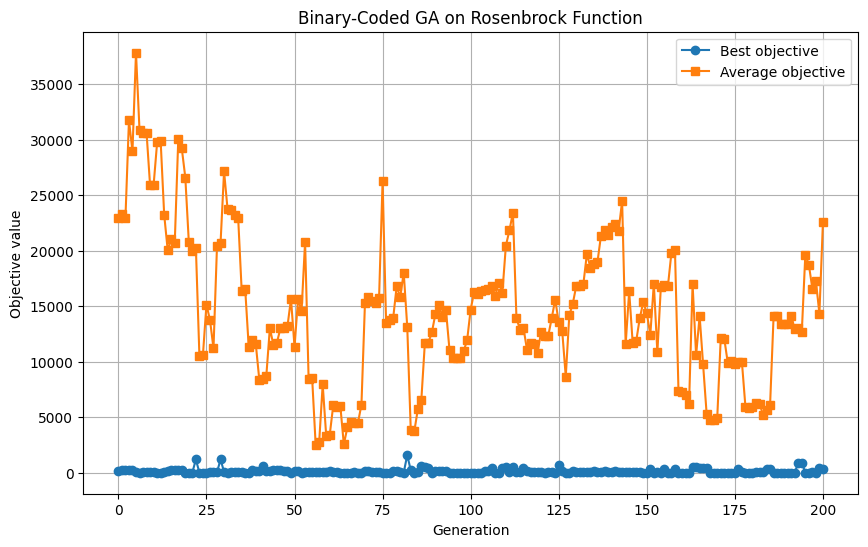

In [4]:
def main():
    # Create the initial population
    population = toolbox.population(n=POP_SIZE)

    # Collect statistics based on fitness values
    stats = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats.register("min", np.min)
    stats.register("avg", np.mean)

    # Store the best individual found during the run
    hof = tools.HallOfFame(1)

    # Run the simple evolutionary algorithm
    population, logbook = algorithms.eaSimple(
    population, toolbox,
    cxpb=CXPB, mutpb=MUTPB,
    ngen=NGEN, stats=stats, halloffame=hof, verbose=True
    )
    
    # Extract the best solution from the Hall of Fame
    best = hof[0]
    dv1, dv2, x1, x2 = decode_individual(best)
    best_f = best.fitness.values[0]

    # Print best solution details
    print("Best chromosome:", "".join(map(str, best)))
    print("DV(x1), DV(x2):", dv1, dv2)
    print("Decoded x1, x2:", round(x1, 3), round(x2, 3))
    print("Best objective:", round(best_f, 6))

    # Extract logged statistics for plotting
    generations = logbook.select("gen")
    min_vals = logbook.select("min")
    avg_vals = logbook.select("avg")

    # Plot best and average objective values over generations
    plt.figure(figsize=(10, 6))
    plt.plot(generations, min_vals, marker="o", label="Best objective")
    plt.plot(generations, avg_vals, marker="s", label="Average objective")
    plt.xlabel("Generation")
    plt.ylabel("Objective value")
    plt.title("Binary-Coded GA on Rosenbrock Function")
    plt.legend()
    plt.grid(True)
    plt.show()

# Run the program only when this file is executed directly
if __name__ == "__main__":
    main()